<a href="https://colab.research.google.com/github/febyataalya/PCVK-Ganjil-2026/blob/main/Week6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**PRAKTIKUM FILTER**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

In [5]:
def convolution2d(image, kernel, stride, padding):
  if padding > 0:
    image_padded = np.pad(
        image,
        ((padding, padding), (padding, padding)),
        mode='constant',
        constant_values=0,
    )
  else:
    image_padded = image

  k_h, k_w = kernel.shape
  i_h, i_w = image_padded.shape

  out_h = (i_h - k_h) // stride + 1
  out_w = (i_w - k_w) // stride + 1

  output = np.zeros((out_h, out_w), dtype=np.float32)

  for y in range(0, out_h):
    for x in range(0, out_w):
      region = image_padded[
          y * stride : y * stride + k_h, x * stride : x * stride + k_w
      ]
      output[y, x] = np.sum(region * kernel)

  return np.clip(output, 0, 255).astype(np.uint8)

In [6]:
img = cv.imread('/content/drive/MyDrive/PCVK 2026/Images/mandrill.tiff')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

In [7]:
kernel_sharpen = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])

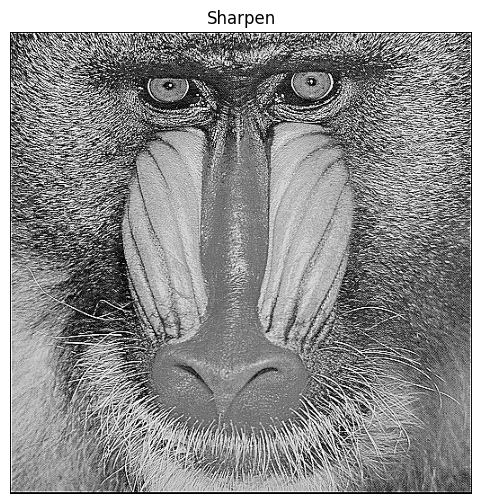

In [8]:
hasil_sharpen = convolution2d(img_gray, kernel_sharpen, 1, 2)

plt.figure(figsize=(6, 6))
plt.imshow(hasil_sharpen, cmap='gray')
plt.title('Sharpen')
plt.axis('off')
plt.show()

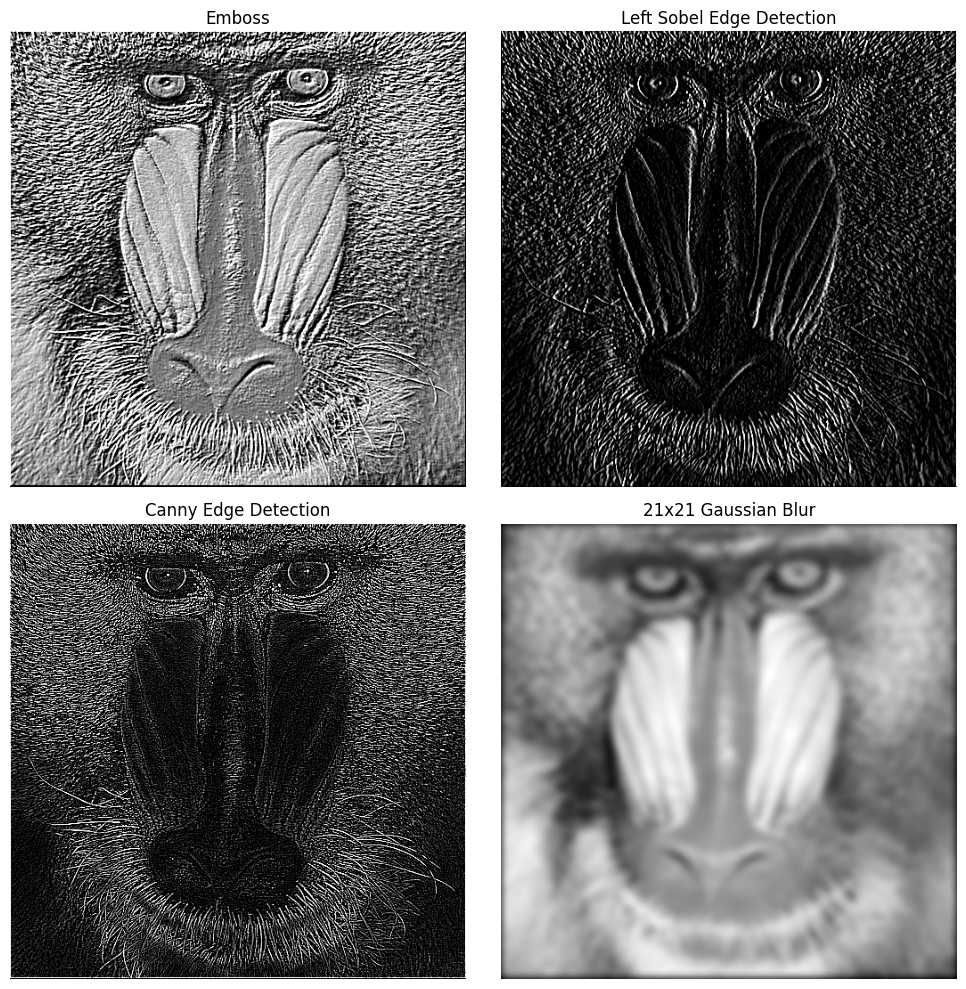

In [9]:
kernel_emboss = np.array([[-2, -1, 0], [-1, 1, 1], [0, 1, 2]])
hasil_emboss = convolution2d(img_gray, kernel_emboss, 1, 1)

kernel_sobel = np.array([[1, 0, -1], [2, 0, -2], [1, 0, -1]])
hasil_sobel = convolution2d(img_gray, kernel_sobel, 1, 1)

kernel_canny = np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]])
hasil_canny = convolution2d(img_gray, kernel_canny, 1, 1)

kernel_size = 21
sigma = math.sqrt(kernel_size)
gaussian_kernel = cv.getGaussianKernel(kernel_size, sigma)
gauss_kernel_2d = gaussian_kernel @ gaussian_kernel.transpose()
hasil_gauss = convolution2d(img_gray, gauss_kernel_2d, 1, kernel_size // 2)

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes[0, 0].imshow(hasil_emboss, cmap='gray')
axes[0, 0].set_title('Emboss')
axes[0, 0].axis('off')

axes[0, 1].imshow(hasil_sobel, cmap='gray')
axes[0, 1].set_title('Left Sobel Edge Detection')
axes[0, 1].axis('off')

axes[1, 0].imshow(hasil_canny, cmap='gray')
axes[1, 0].set_title('Canny Edge Detection')
axes[1, 0].axis('off')

axes[1, 1].imshow(hasil_gauss, cmap='gray')
axes[1, 1].set_title('21x21 Gaussian Blur')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

**FILTER LIBRARY DAN FILTER MODERN**

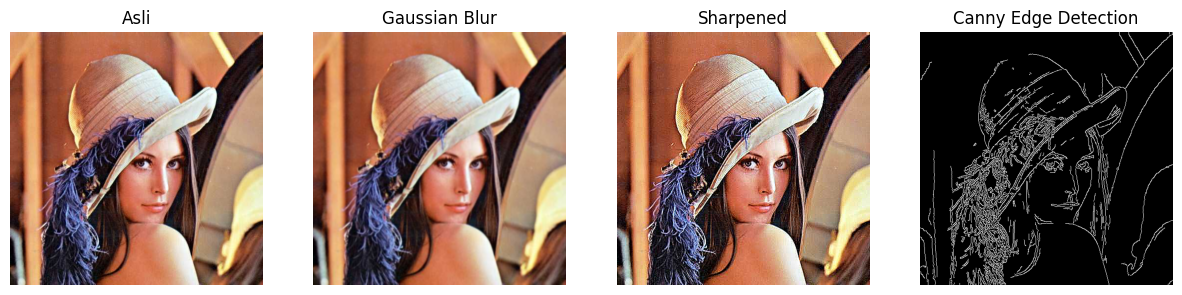

In [13]:
# Fungsi tampil berdampingan
def show_side_by_side(images, titles, figsize=(15, 5)):
  plt.figure(figsize=figsize)
  for i, (img, title) in enumerate(zip(images, titles)):
    if len(img.shape) == 2:  # grayscale
      plt.subplot(1, len(images), i + 1)
      plt.imshow(img, cmap="gray")
    else:  # color
      plt.subplot(1, len(images), i + 1)
      plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
  plt.show()


img = cv.imread(
    "/content/drive/MyDrive/PCVK 2026/Images/lena.jpg"
)
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

blur = cv.GaussianBlur(img, (7, 7), 1)
edges = cv.Canny(cv.cvtColor(img, cv.COLOR_BGR2GRAY), 100, 200)
sharpen_kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
sharpened = cv.filter2D(img, -1, sharpen_kernel)
show_side_by_side(
    [img, blur, sharpened, edges],
    ["Asli", "Gaussian Blur", "Sharpened", "Canny Edge Detection"])


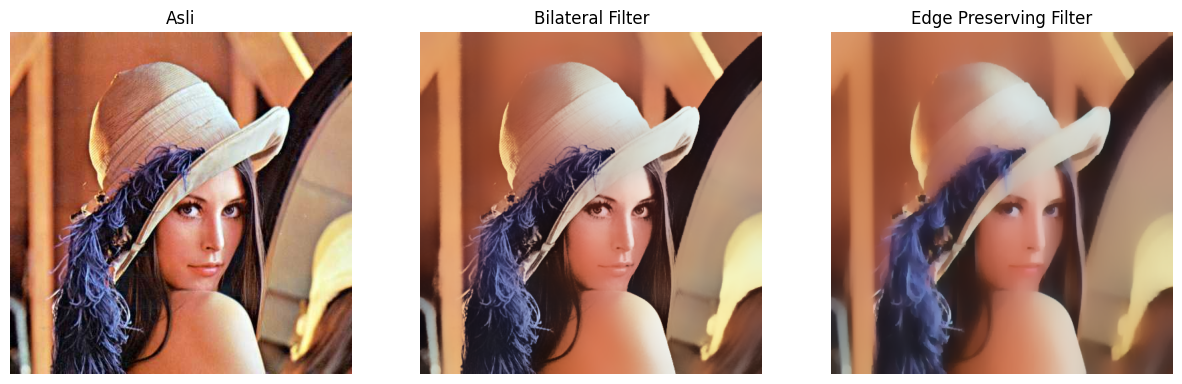

In [14]:
# Filter Modern dari OpenCV
# Bilateral Filter (edge-preserving)
bilateral = cv.bilateralFilter(img, 50, 100, 100)

# Edge Preserving Filter (alternatif Guided Filter)
edge_preserve = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)

show_side_by_side(
    [img, bilateral, edge_preserve],
    ["Asli", "Bilateral Filter", "Edge Preserving Filter"],
)